# NGBoost hyperparameter tuning

In [1]:
# Load data

import pandas as pd
import numpy as np 

train_df = pd.read_parquet("data/train_data.parquet")

train_df.index = pd.to_numeric(train_df.index, errors="coerce")

cols_to_drop = ["issue_d", "earliest_cr_line"]
train_df = train_df.drop(columns=cols_to_drop, errors="ignore")

In [2]:
# Separate features and targets

train_full_X = train_df.drop(["target", "target_annual_roi"], axis=1)
train_full_y_cat = train_df["target"]
train_full_y_reg = train_df["target_annual_roi"]

# Drop datetime features from the feature set

cols_to_drop = ["issue_d", "earliest_cr_line"]
train_full_X = train_full_X.drop(columns=cols_to_drop, errors="ignore")

In [3]:
# Create subsets of the data for different training sizes - chronplogical order is preserved, so we take the last N rows for each subset

train_1k_X = train_full_X.tail(1000)
train_1k_y_cat = train_full_y_cat.tail(1000)
train_1k_y_reg = train_full_y_reg.tail(1000)

train_10k_X = train_full_X.tail(10000)
train_10k_y_cat = train_full_y_cat.tail(10000)
train_10k_y_reg = train_full_y_reg.tail(10000)

train_100k_X = train_full_X.tail(100000)
train_100k_y_cat = train_full_y_cat.tail(100000)
train_100k_y_reg = train_full_y_reg.tail(100000)

In [4]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

cols_to_nominal_cat = train_df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
for col in cols_to_nominal_cat:
    print(f"- {col}")

cardinality = train_df[cols_to_nominal_cat].nunique()
threshold_for_ohe = 5

cols_for_ohe = cardinality[cardinality <= threshold_for_ohe].index.tolist()
cols_for_te = cardinality[cardinality > threshold_for_ohe].index.tolist()

ohe_categories = []
for col in cols_for_ohe:
    unique_cats = train_df[col].dropna().unique().tolist()
    ohe_categories.append(unique_cats)

ohe_transformer = OneHotEncoder(
    categories=ohe_categories, 
    drop="if_binary", 
    handle_unknown="ignore", 
    sparse_output=False
)

target_transformer_nominal = TargetEncoder(target_type="binary", smooth="auto")

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", ohe_transformer, cols_for_ohe),
        ("target_enc", target_transformer_nominal, cols_for_te)
    ],
    remainder="passthrough", 
    verbose_feature_names_out=False
).set_output(transform="pandas")

imputed_numeric_preprocessor = make_pipeline(
    numeric_preprocessor,
    SimpleImputer(strategy="median")
).set_output(transform="pandas")

gbdt_preprocessor = "passthrough"

Categorical columns:
- home_ownership
- verification_status
- purpose
- addr_state
- initial_list_status
- application_type
- disbursement_method


## Classification

[Parameters NGBoost](https://stanfordmlgroup.github.io/ngboost/1-useage.html)
[Parameters base learner](https://scikit-learn.org/1.6/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

### 1k

In [5]:
# Check the dates of 1k subset to ensure all data is from same month

print(train_1k_X["issue_d_month"].unique())
print(train_1k_X["issue_d_year"].unique())

<IntegerArray>
[10]
Length: 1, dtype: Int64
<IntegerArray>
[2016]
Length: 1, dtype: Int64


In [6]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order

X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_cat.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_cat.head(200)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 15, 100), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 0.8), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)


        weights = compute_sample_weight(class_weight="balanced", y=y_tr)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_1k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_1k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_1k_parallel.html")


[I 2026-04-25 12:54:20,156] A new study created in memory with name: no-name-47251cdd-f57f-4fe9-856d-a5a16efde303
/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
[I 2026-04-25 12:54:27,768] Trial 5 finished with value: 0.6588073420832042 and parameters: {'base_max_depth': 4, 'base_min_samples_split': 15, 'base_min_samples_leaf': 69, 'base_min_weight_fraction_leaf': 0.003110238042117297, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.0006135607751668387, 'base_max_leaf_nodes': 26, 'base_min_impurity_decrease': 0.9985451552020964, 'n_estimators': 153, 'learning_rate': 0.01873551232166193, 'minibatch_frac': 0.7059520180774161, 'col_sample': 0.650106816354148

KeyboardInterrupt: 

In [ ]:
best_params = study_ngboost.best_params.copy()

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["Dist"] = Bernoulli
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBClassifier(Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

BEST PARAMS: {'n_estimators': 458, 'learning_rate': 0.016713887036469623, 'minibatch_frac': 0.989930969209853, 'col_sample': 0.5500433591716888, 'random_state': 42, 'verbose': False}

Optuna Val AUC:   0.6828
Holdout Test AUC: 0.6737


### 10k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning

X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_cat.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_cat.tail(2000)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 15, 100), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 0.8), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)


        weights = compute_sample_weight(class_weight="balanced", y=y_tr)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_10k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_10k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_10k_parallel.html")


[I 2026-04-23 18:34:34,108] A new study created in memory with name: no-name-3ce29394-59fd-4af9-8b15-243f40772471
[I 2026-04-23 18:35:00,056] Trial 7 finished with value: 0.6830816430094039 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 88, 'base_min_samples_leaf': 32, 'base_min_weight_fraction_leaf': 0.21708888508647667, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.046773041266246033, 'base_max_leaf_nodes': 12, 'base_min_impurity_decrease': 0.7038484824574064, 'n_estimators': 113, 'learning_rate': 0.009970496637937452, 'minibatch_frac': 0.6470956203354629, 'col_sample': 0.3313805757609103}. Best is trial 7 with value: 0.6830816430094039.
[I 2026-04-23 18:35:04,104] Trial 6 finished with value: 0.6889916422599459 and parameters: {'base_max_depth': 3, 'base_min_samples_split': 37, 'base_min_samples_leaf': 70, 'base_min_weight_fraction_leaf': 0.20393489736521858, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.02622588923685184, 'base_max_leaf_nodes': 21, 'base_min_


BEST AUC: 0.6953
BEST PARAMETERS:
best_params = {
    "base_max_depth": 4,
    "base_min_samples_split": 87,
    "base_min_samples_leaf": 75,
    "base_min_weight_fraction_leaf": 0.02993682051819463,
    "base_max_features": "log2",
    "base_ccp_alpha": 0.010829993711708636,
    "base_max_leaf_nodes": 13,
    "base_min_impurity_decrease": 0.45635714253899073,
    "n_estimators": 776,
    "learning_rate": 0.011684267369390813,
    "minibatch_frac": 0.7132080775795577,
    "col_sample": 0.6217118499392622,
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.3076
  col_sample          : 0.1784
  base_min_weight_fraction_leaf: 0.1379
  base_min_samples_leaf: 0.1376
  base_max_leaf_nodes : 0.1036
  base_ccp_alpha      : 0.0432
  base_max_features   : 0.0360
  n_estimators        : 0.0349
  base_min_samples_split: 0.0086
  minibatch_frac      : 0.0062
  base_min_impurity_decrease: 0.0052
  base_max_depth      : 0.0009


In [ ]:
best_params = study_ngboost.best_params.copy()

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBClassifier(Dist=Bernoulli, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)


Optuna Val AUC:   0.6953
Holdout Test AUC: 0.6910


### 100k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_cat.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_cat.tail(20000)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 10, 500), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 1.0), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)


        weights = compute_sample_weight(class_weight="balanced", y=y_tr)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_100k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_100k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_100k_parallel.html")


[I 2026-04-23 18:38:03,836] A new study created in memory with name: no-name-a1f512d6-7b92-4ac4-8c4f-d2fc5ace8fb0
[I 2026-04-23 18:40:25,868] Trial 6 finished with value: 0.6921303894103804 and parameters: {'base_max_depth': 2, 'base_min_samples_split': 133, 'base_min_samples_leaf': 126, 'base_min_weight_fraction_leaf': 0.2236317504121469, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.007780247023294528, 'base_max_leaf_nodes': 221, 'base_min_impurity_decrease': 0.135931486938753, 'n_estimators': 139, 'learning_rate': 0.12662162500968235, 'minibatch_frac': 0.6409471712323819, 'col_sample': 0.9995018725903868}. Best is trial 6 with value: 0.6921303894103804.
[I 2026-04-23 18:40:35,357] Trial 1 finished with value: 0.6809589234616655 and parameters: {'base_max_depth': 19, 'base_min_samples_split': 166, 'base_min_samples_leaf': 427, 'base_min_weight_fraction_leaf': 0.30757891867228054, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.018064797763421996, 'base_max_leaf_nodes': 247, 'base


BEST AUC: 0.6962
BEST PARAMETERS:
best_params = {
    "base_max_depth": 17,
    "base_min_samples_split": 124,
    "base_min_samples_leaf": 40,
    "base_min_weight_fraction_leaf": 0.04152938055081268,
    "base_max_features": None,
    "base_ccp_alpha": 6.591823789141138e-05,
    "base_max_leaf_nodes": 295,
    "base_min_impurity_decrease": 0.8187417527233122,
    "n_estimators": 949,
    "learning_rate": 0.13483255765269922,
    "minibatch_frac": 0.8188389001781762,
    "col_sample": 0.801290016773104,
}

--- PARAMETER IMPORTANCE ---
  base_min_weight_fraction_leaf: 0.2037
  base_min_samples_split: 0.1805
  base_min_samples_leaf: 0.1291
  base_ccp_alpha      : 0.1272
  minibatch_frac      : 0.0988
  n_estimators        : 0.0667
  base_max_depth      : 0.0666
  learning_rate       : 0.0440
  base_max_leaf_nodes : 0.0423
  base_min_impurity_decrease: 0.0344
  col_sample          : 0.0046
  base_max_features   : 0.0020


In [ ]:
best_params = study_ngboost.best_params.copy()

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBClassifier(Dist=Bernoulli, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

### Whole training data set

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*4
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

split_index = int(len(train_full_X) * 0.8)

X_tuning = train_full_X[:split_index]
y_tuning = train_full_y_cat[:split_index]
X_val_holdout = train_full_X[split_index:]
y_val_holdout = train_full_y_cat[split_index:]

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 10, 500), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 1.0), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)


        weights = compute_sample_weight(class_weight="balanced", y=y_tr)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_full_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_full_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_full_parallel.html")


[I 2026-04-22 00:55:36,440] A new study created in memory with name: no-name-e6e86f3f-4af6-4c6c-bb30-bebed2ab97f3
[I 2026-04-22 00:56:27,391] Trial 3 finished with value: 0.7509030339384353 and parameters: {'boosting_type': 'goss', 'num_leaves': 377, 'max_depth': 2, 'learning_rate': 0.1903428179678173, 'scale_pos_weight': 6.082125486473243, 'min_split_gain': 26.39142477642419, 'min_child_weight': 4.8185524092618045e-05, 'min_child_samples': 290, 'colsample_bytree': 0.5066837006445346, 'reg_alpha': 0.008590451603378712, 'reg_lambda': 0.0006321751034820287, 'colsample_bynode': 0.6989172440719156, 'min_data_per_group': 976, 'max_cat_threshold': 632, 'cat_l2': 4.676533112163103e-06, 'cat_smooth': 34.70861426629406, 'max_cat_to_onehot': 37, 'max_bin': 433, 'top_rate': 0.7237115739628408, 'other_rate': 0.1719406111579936, 'n_estimators': 6050}. Best is trial 3 with value: 0.7509030339384353.
[I 2026-04-22 00:56:59,196] Trial 6 finished with value: 0.7442250170611076 and parameters: {'boostin


BEST AUC: 0.7566
BEST PARAMETERS:
best_params = {
    "boosting_type": "goss",
    "num_leaves": 298,
    "max_depth": 20,
    "learning_rate": 0.002488325776616227,
    "scale_pos_weight": 5.888271675991455,
    "min_split_gain": 1.6197064284930547,
    "min_child_weight": 0.0002644551677947709,
    "min_child_samples": 371,
    "colsample_bytree": 0.5316730321670442,
    "reg_alpha": 0.000426119399156468,
    "reg_lambda": 10.280323813334233,
    "colsample_bynode": 0.5281296236914715,
    "min_data_per_group": 996,
    "max_cat_threshold": 678,
    "cat_l2": 1.640465366517915e-08,
    "cat_smooth": 22.561055503199018,
    "max_cat_to_onehot": 45,
    "max_bin": 454,
    "top_rate": 0.18095067523535055,
    "other_rate": 0.31987875938170135,
    "n_estimators": 6725,
}

--- PARAMETER IMPORTANCE ---
  max_depth           : 0.2899
  min_data_per_group  : 0.1874
  max_bin             : 0.1858
  boosting_type       : 0.0868
  learning_rate       : 0.0573
  min_child_samples   : 0.0480
 

In [ ]:
best_params = study_ngboost.best_params.copy()

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBClassifier(Dist=Bernoulli, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

Optuna Val AUC: 0.7566
Holdout Test AUC: 0.7298


## Regression

[Parameters NGBoost](https://stanfordmlgroup.github.io/ngboost/1-useage.html)
[Parameters base learner](https://scikit-learn.org/1.6/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

### 1k

In [5]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

cols_to_nominal_cat = train_df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
for col in cols_to_nominal_cat:
    print(f"- {col}")

cardinality = train_df[cols_to_nominal_cat].nunique()
threshold_for_ohe = 5

cols_for_ohe = cardinality[cardinality <= threshold_for_ohe].index.tolist()
cols_for_te = cardinality[cardinality > threshold_for_ohe].index.tolist()

ohe_categories = []
for col in cols_for_ohe:
    unique_cats = train_df[col].dropna().unique().tolist()
    ohe_categories.append(unique_cats)

ohe_transformer = OneHotEncoder(
    categories=ohe_categories, 
    drop="if_binary", 
    handle_unknown="ignore", 
    sparse_output=False
)

target_transformer_nominal = TargetEncoder(target_type="continuous", smooth="auto")

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", ohe_transformer, cols_for_ohe),
        ("target_enc", target_transformer_nominal, cols_for_te)
    ],
    remainder="passthrough", 
    verbose_feature_names_out=False
).set_output(transform="pandas")

imputed_numeric_preprocessor = make_pipeline(
    numeric_preprocessor,
    SimpleImputer(strategy="median")
).set_output(transform="pandas")

gbdt_preprocessor = "passthrough"

Categorical columns:
- home_ownership
- verification_status
- purpose
- addr_state
- initial_list_status
- application_type
- disbursement_method


In [15]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal, Laplace
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*0.01
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order

X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_reg.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_reg.head(200)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 15, 100), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 0.8), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])
    
    # Map the string to the imported class
    dist_mapping = {
        "Normal": Normal, 
        "Laplace": Laplace
    }
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_1k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_1k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_1k_parallel.html")


[I 2026-04-25 14:17:41,617] A new study created in memory with name: no-name-c1e54078-2199-44b7-a027-51ed33817334
[I 2026-04-25 14:19:02,214] Trial 0 finished with value: 0.3227050341868802 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 19, 'base_min_samples_leaf': 77, 'base_min_weight_fraction_leaf': 0.3345657552829118, 'base_max_features': 'log2', 'base_ccp_alpha': 0.06964031348160273, 'base_max_leaf_nodes': 10, 'base_min_impurity_decrease': 0.11708639403572652, 'n_estimators': 261, 'learning_rate': 0.023822884688274773, 'minibatch_frac': 0.6044537585748054, 'col_sample': 0.6552006913351799, 'Dist': 'Normal'}. Best is trial 0 with value: 0.3227050341868802.
[I 2026-04-25 14:19:12,282] Trial 4 finished with value: 0.3512021170893323 and parameters: {'base_max_depth': 3, 'base_min_samples_split': 81, 'base_min_samples_leaf': 85, 'base_min_weight_fraction_leaf': 0.3745915546397449, 'base_max_features': 'sqrt', 'base_ccp_alpha': 5.6599314721782575e-05, 'base_max_leaf_nod


BEST RMSE: 0.3179
BEST PARAMETERS:
best_params = {
    "base_max_depth": 5,
    "base_min_samples_split": 54,
    "base_min_samples_leaf": 64,
    "base_min_weight_fraction_leaf": 0.1630594618823329,
    "base_max_features": "log2",
    "base_ccp_alpha": 7.572812676721209e-05,
    "base_max_leaf_nodes": 3,
    "base_min_impurity_decrease": 0.4326075078722952,
    "n_estimators": 801,
    "learning_rate": 0.0066691599607614825,
    "minibatch_frac": 0.7465767314715719,
    "col_sample": 0.3083921111857588,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.2781
  minibatch_frac      : 0.1876
  col_sample          : 0.1718
  base_max_depth      : 0.1083
  base_ccp_alpha      : 0.0802
  base_min_samples_split: 0.0473
  learning_rate       : 0.0313
  base_max_features   : 0.0307
  base_max_leaf_nodes : 0.0296
  base_min_weight_fraction_leaf: 0.0163
  base_min_samples_leaf: 0.0162
  n_estimators        : 0.0018
  base_min_impurity_decrease: 0.0009


In [16]:
best_params = study_ngboost.best_params.copy()

best_dist_str = best_params.pop("Dist")
dist_mapping = {
    "Normal": Normal, 
    "Laplace": Laplace
}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps['ngbregressor'].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale

holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 5, 'min_samples_split': 54, 'min_samples_leaf': 64, 'min_weight_fraction_leaf': 0.1630594618823329, 'max_features': 'log2', 'ccp_alpha': 7.572812676721209e-05, 'max_leaf_nodes': 3, 'min_impurity_decrease': 0.4326075078722952, 'random_state': 42}
BEST PARAMS: {'n_estimators': 801, 'learning_rate': 0.0066691599607614825, 'minibatch_frac': 0.7465767314715719, 'col_sample': 0.3083921111857588, 'random_state': 42, 'verbose': False}

Optuna Val RMSE:   0.3179
Holdout Test RMSE: 0.3350


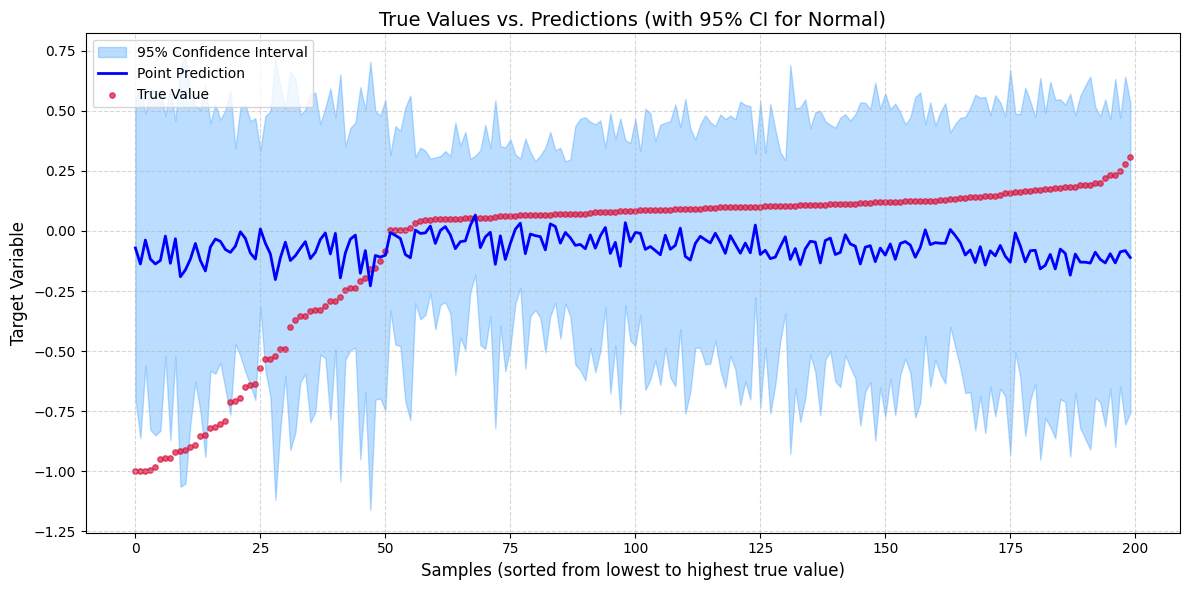

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace, t

dist_name = best_dist_str

if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')
plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')
plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')
plt.title(f'True Values vs. Predictions (with 95% CI for {dist_name})', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

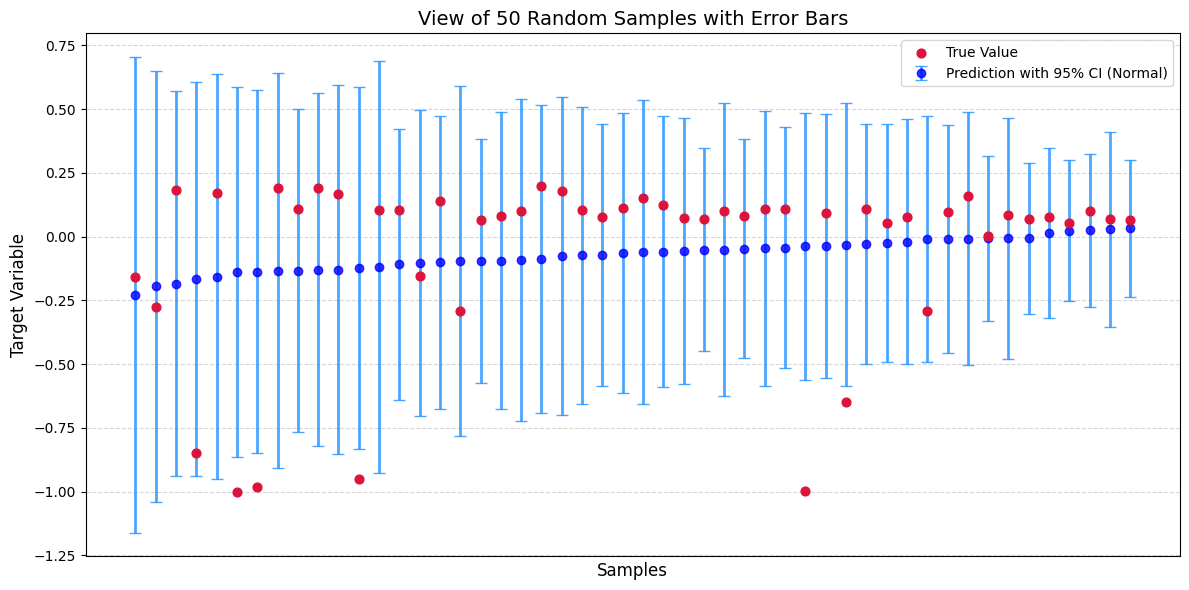

: 

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

plt.figure(figsize=(12, 6))
plt.errorbar(range(n_samples), y_pred_sample, yerr=[yerr_lower, yerr_upper], 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label=f'Prediction with 95% CI ({dist_name})')
plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')
plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 10k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

# Parameter tuning settings

timeout_seconds = 60*60*0.5
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning

X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_reg.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_reg.tail(2000)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 15, 100), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 0.8), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])
    
    # Map the string to the imported class
    dist_mapping = {
        "Normal": Normal, 
        "Laplace": Laplace
    }
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_10k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_10k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_10k_parallel.html")


[I 2026-04-23 18:34:34,108] A new study created in memory with name: no-name-3ce29394-59fd-4af9-8b15-243f40772471
[I 2026-04-23 18:35:00,056] Trial 7 finished with value: 0.6830816430094039 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 88, 'base_min_samples_leaf': 32, 'base_min_weight_fraction_leaf': 0.21708888508647667, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.046773041266246033, 'base_max_leaf_nodes': 12, 'base_min_impurity_decrease': 0.7038484824574064, 'n_estimators': 113, 'learning_rate': 0.009970496637937452, 'minibatch_frac': 0.6470956203354629, 'col_sample': 0.3313805757609103}. Best is trial 7 with value: 0.6830816430094039.
[I 2026-04-23 18:35:04,104] Trial 6 finished with value: 0.6889916422599459 and parameters: {'base_max_depth': 3, 'base_min_samples_split': 37, 'base_min_samples_leaf': 70, 'base_min_weight_fraction_leaf': 0.20393489736521858, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.02622588923685184, 'base_max_leaf_nodes': 21, 'base_min_


BEST AUC: 0.6953
BEST PARAMETERS:
best_params = {
    "base_max_depth": 4,
    "base_min_samples_split": 87,
    "base_min_samples_leaf": 75,
    "base_min_weight_fraction_leaf": 0.02993682051819463,
    "base_max_features": "log2",
    "base_ccp_alpha": 0.010829993711708636,
    "base_max_leaf_nodes": 13,
    "base_min_impurity_decrease": 0.45635714253899073,
    "n_estimators": 776,
    "learning_rate": 0.011684267369390813,
    "minibatch_frac": 0.7132080775795577,
    "col_sample": 0.6217118499392622,
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.3076
  col_sample          : 0.1784
  base_min_weight_fraction_leaf: 0.1379
  base_min_samples_leaf: 0.1376
  base_max_leaf_nodes : 0.1036
  base_ccp_alpha      : 0.0432
  base_max_features   : 0.0360
  n_estimators        : 0.0349
  base_min_samples_split: 0.0086
  minibatch_frac      : 0.0062
  base_min_impurity_decrease: 0.0052
  base_max_depth      : 0.0009


In [ ]:
best_params = study_ngboost.best_params.copy()

best_dist_str = best_params.pop("Dist")
dist_mapping = {
    "Normal": Normal, 
    "Laplace": Laplace
}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps['ngbregressor'].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale

holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)


Optuna Val AUC:   0.6953
Holdout Test AUC: 0.6910


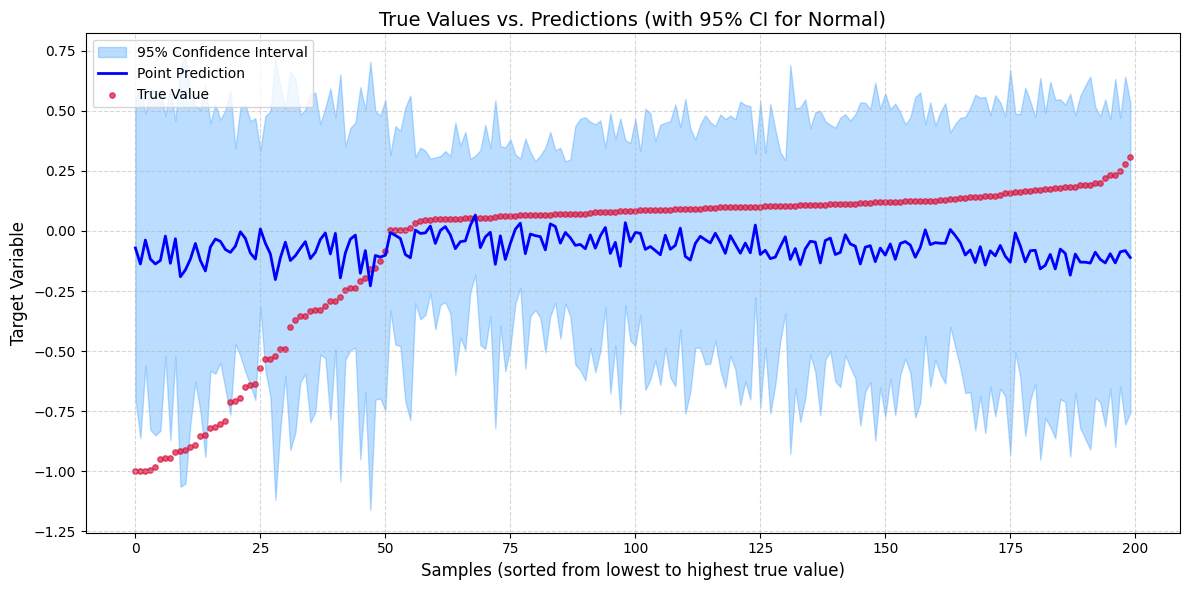

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace, t

dist_name = best_dist_str

if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')
plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')
plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')
plt.title(f'True Values vs. Predictions (with 95% CI for {dist_name})', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

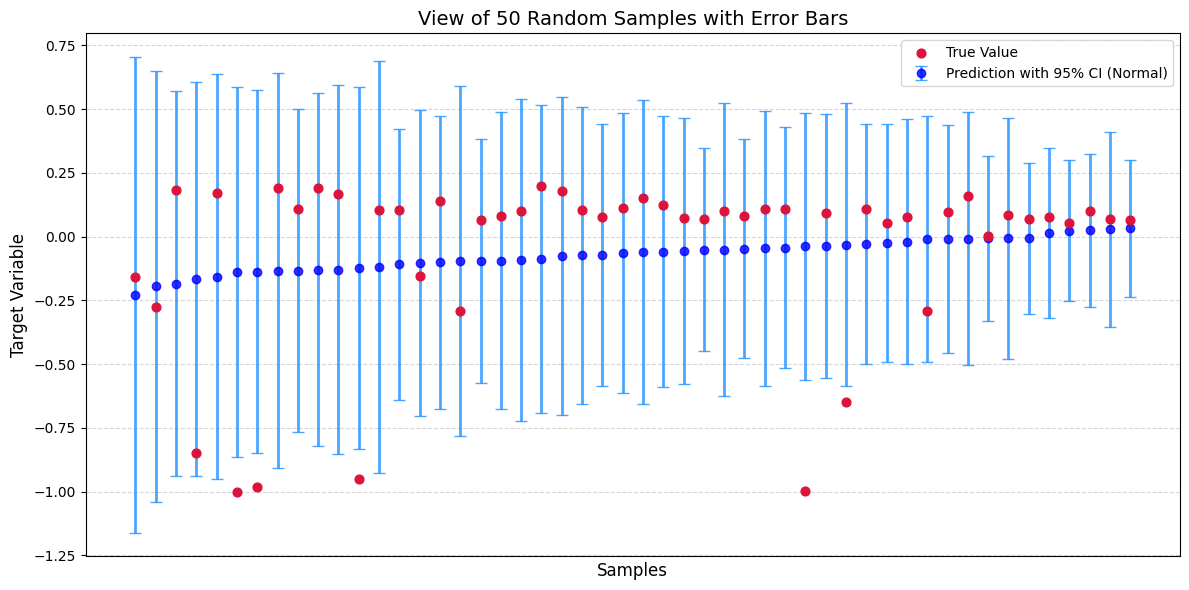

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

plt.figure(figsize=(12, 6))
plt.errorbar(range(n_samples), y_pred_sample, yerr=[yerr_lower, yerr_upper], 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label=f'Prediction with 95% CI ({dist_name})')
plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')
plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 100k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

# Parameter tuning settings

timeout_seconds = 60*60*3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_reg.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_reg.tail(20000)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 10, 500), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 1.0), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])
    
    # Map the string to the imported class
    dist_mapping = {
        "Normal": Normal, 
        "Laplace": Laplace
    }
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_100k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_100k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_100k_parallel.html")


[I 2026-04-23 18:38:03,836] A new study created in memory with name: no-name-a1f512d6-7b92-4ac4-8c4f-d2fc5ace8fb0
[I 2026-04-23 18:40:25,868] Trial 6 finished with value: 0.6921303894103804 and parameters: {'base_max_depth': 2, 'base_min_samples_split': 133, 'base_min_samples_leaf': 126, 'base_min_weight_fraction_leaf': 0.2236317504121469, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.007780247023294528, 'base_max_leaf_nodes': 221, 'base_min_impurity_decrease': 0.135931486938753, 'n_estimators': 139, 'learning_rate': 0.12662162500968235, 'minibatch_frac': 0.6409471712323819, 'col_sample': 0.9995018725903868}. Best is trial 6 with value: 0.6921303894103804.
[I 2026-04-23 18:40:35,357] Trial 1 finished with value: 0.6809589234616655 and parameters: {'base_max_depth': 19, 'base_min_samples_split': 166, 'base_min_samples_leaf': 427, 'base_min_weight_fraction_leaf': 0.30757891867228054, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.018064797763421996, 'base_max_leaf_nodes': 247, 'base


BEST AUC: 0.6962
BEST PARAMETERS:
best_params = {
    "base_max_depth": 17,
    "base_min_samples_split": 124,
    "base_min_samples_leaf": 40,
    "base_min_weight_fraction_leaf": 0.04152938055081268,
    "base_max_features": None,
    "base_ccp_alpha": 6.591823789141138e-05,
    "base_max_leaf_nodes": 295,
    "base_min_impurity_decrease": 0.8187417527233122,
    "n_estimators": 949,
    "learning_rate": 0.13483255765269922,
    "minibatch_frac": 0.8188389001781762,
    "col_sample": 0.801290016773104,
}

--- PARAMETER IMPORTANCE ---
  base_min_weight_fraction_leaf: 0.2037
  base_min_samples_split: 0.1805
  base_min_samples_leaf: 0.1291
  base_ccp_alpha      : 0.1272
  minibatch_frac      : 0.0988
  n_estimators        : 0.0667
  base_max_depth      : 0.0666
  learning_rate       : 0.0440
  base_max_leaf_nodes : 0.0423
  base_min_impurity_decrease: 0.0344
  col_sample          : 0.0046
  base_max_features   : 0.0020


In [ ]:
best_params = study_ngboost.best_params.copy()

best_dist_str = best_params.pop("Dist")
dist_mapping = {
    "Normal": Normal, 
    "Laplace": Laplace
}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps['ngbregressor'].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale

holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

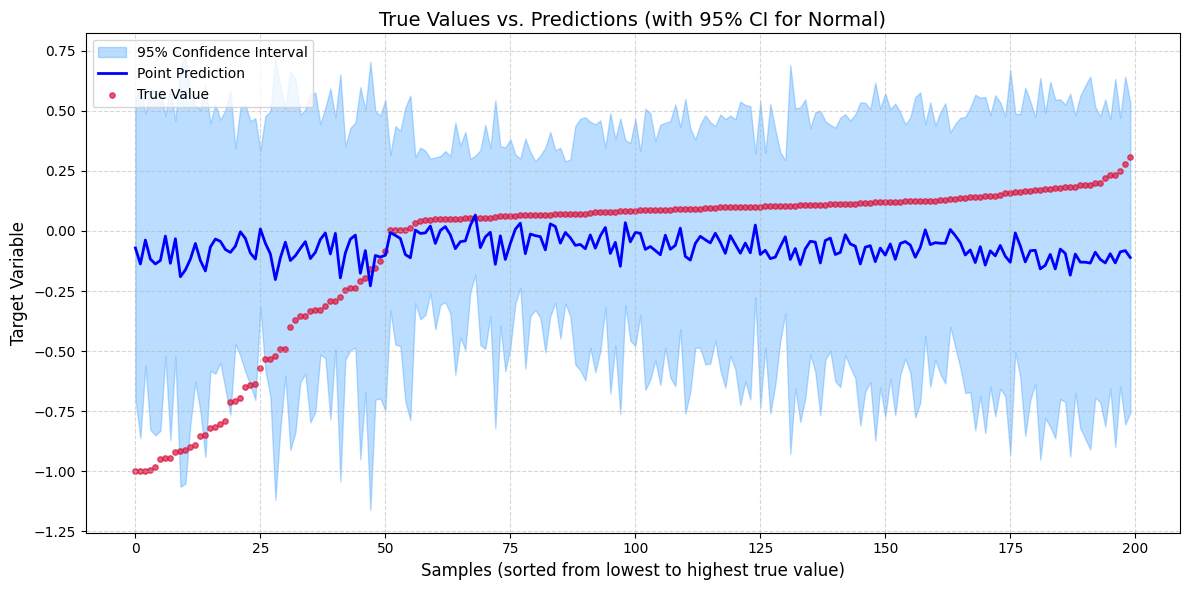

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace, t

dist_name = best_dist_str

if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')
plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')
plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')
plt.title(f'True Values vs. Predictions (with 95% CI for {dist_name})', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

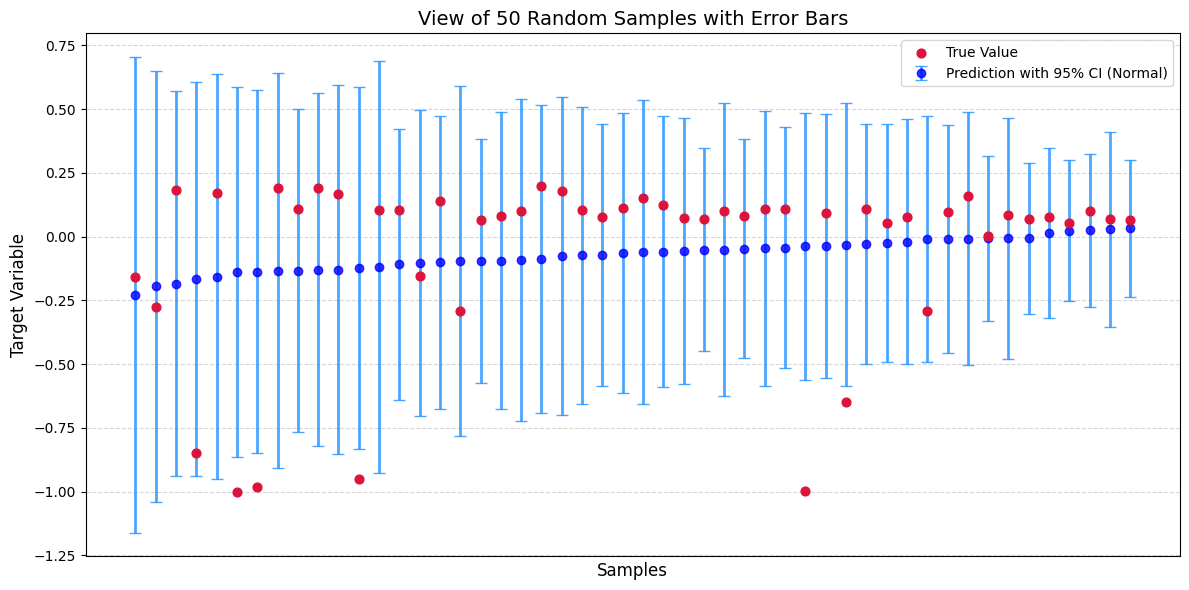

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

plt.figure(figsize=(12, 6))
plt.errorbar(range(n_samples), y_pred_sample, yerr=[yerr_lower, yerr_upper], 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label=f'Prediction with 95% CI ({dist_name})')
plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')
plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Whole training data set

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*4
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

split_index = int(len(train_full_X) * 0.8)

X_tuning = train_full_X[:split_index]
y_tuning = train_full_y_reg[:split_index]
X_val_holdout = train_full_X[split_index:]
y_val_holdout = train_full_y_reg[split_index:]

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 10, 500), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 1.0), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])
    
    # Map the string to the imported class
    dist_mapping = {
        "Normal": Normal, 
        "Laplace": Laplace
    }
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_full_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_full_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_full_parallel.html")


[I 2026-04-22 00:55:36,440] A new study created in memory with name: no-name-e6e86f3f-4af6-4c6c-bb30-bebed2ab97f3
[I 2026-04-22 00:56:27,391] Trial 3 finished with value: 0.7509030339384353 and parameters: {'boosting_type': 'goss', 'num_leaves': 377, 'max_depth': 2, 'learning_rate': 0.1903428179678173, 'scale_pos_weight': 6.082125486473243, 'min_split_gain': 26.39142477642419, 'min_child_weight': 4.8185524092618045e-05, 'min_child_samples': 290, 'colsample_bytree': 0.5066837006445346, 'reg_alpha': 0.008590451603378712, 'reg_lambda': 0.0006321751034820287, 'colsample_bynode': 0.6989172440719156, 'min_data_per_group': 976, 'max_cat_threshold': 632, 'cat_l2': 4.676533112163103e-06, 'cat_smooth': 34.70861426629406, 'max_cat_to_onehot': 37, 'max_bin': 433, 'top_rate': 0.7237115739628408, 'other_rate': 0.1719406111579936, 'n_estimators': 6050}. Best is trial 3 with value: 0.7509030339384353.
[I 2026-04-22 00:56:59,196] Trial 6 finished with value: 0.7442250170611076 and parameters: {'boostin


BEST AUC: 0.7566
BEST PARAMETERS:
best_params = {
    "boosting_type": "goss",
    "num_leaves": 298,
    "max_depth": 20,
    "learning_rate": 0.002488325776616227,
    "scale_pos_weight": 5.888271675991455,
    "min_split_gain": 1.6197064284930547,
    "min_child_weight": 0.0002644551677947709,
    "min_child_samples": 371,
    "colsample_bytree": 0.5316730321670442,
    "reg_alpha": 0.000426119399156468,
    "reg_lambda": 10.280323813334233,
    "colsample_bynode": 0.5281296236914715,
    "min_data_per_group": 996,
    "max_cat_threshold": 678,
    "cat_l2": 1.640465366517915e-08,
    "cat_smooth": 22.561055503199018,
    "max_cat_to_onehot": 45,
    "max_bin": 454,
    "top_rate": 0.18095067523535055,
    "other_rate": 0.31987875938170135,
    "n_estimators": 6725,
}

--- PARAMETER IMPORTANCE ---
  max_depth           : 0.2899
  min_data_per_group  : 0.1874
  max_bin             : 0.1858
  boosting_type       : 0.0868
  learning_rate       : 0.0573
  min_child_samples   : 0.0480
 

In [ ]:
best_params = study_ngboost.best_params.copy()

best_dist_str = best_params.pop("Dist")
dist_mapping = {
    "Normal": Normal, 
    "Laplace": Laplace
}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps['ngbregressor'].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale

holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

Optuna Val AUC: 0.7566
Holdout Test AUC: 0.7298


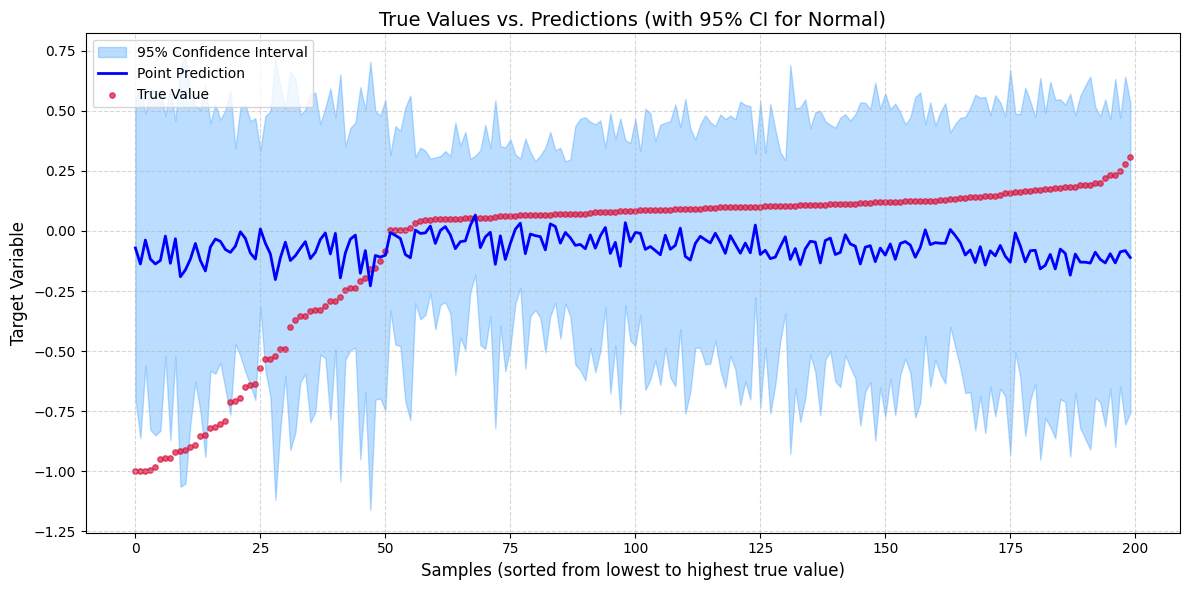

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace, t

dist_name = best_dist_str

if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')
plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')
plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')
plt.title(f'True Values vs. Predictions (with 95% CI for {dist_name})', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

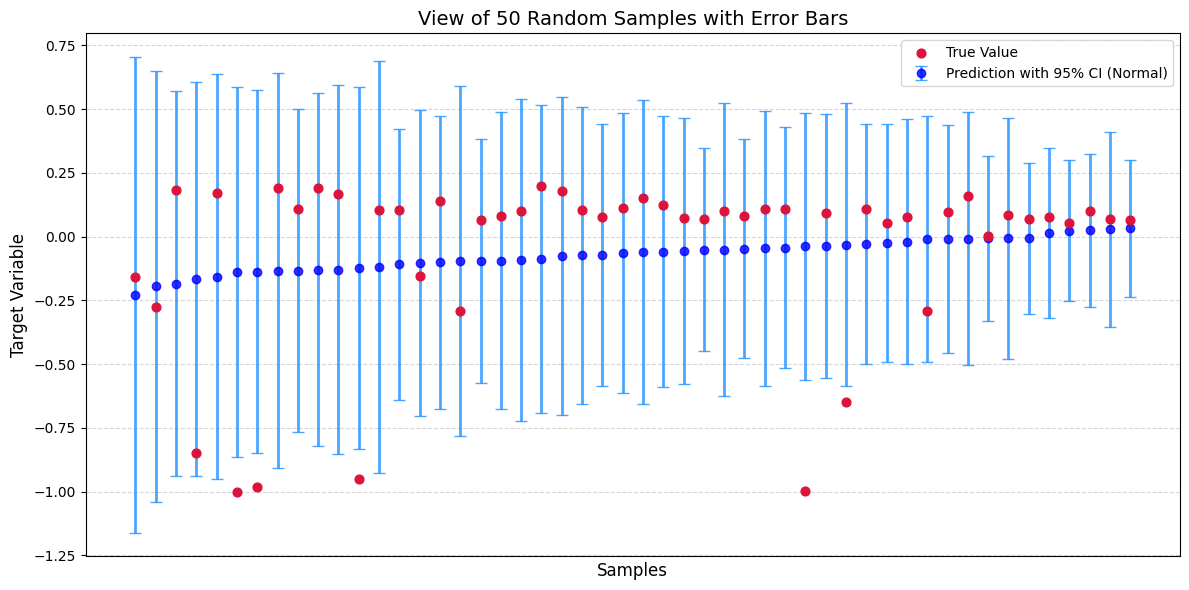

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

plt.figure(figsize=(12, 6))
plt.errorbar(range(n_samples), y_pred_sample, yerr=[yerr_lower, yerr_upper], 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label=f'Prediction with 95% CI ({dist_name})')
plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')
plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()